## CAP STOCK PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

cap=pd.read_csv('../stock_data/cap.csv') ## so it can be small letter. This is cool.
cap=cap.drop(columns=['high_price','low_price'])
cap.rename(columns={'trade_date':'date'},inplace=True)
cap['date']=pd.to_datetime(cap['date'])
cap['month']=cap['date'].dt.month
cap['quarter']=cap['date'].dt.quarter
cap['year']=cap['date'].dt.year

cap

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42841,CAP,2017-01-03,32.00,32.00,5100,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43401,CAP,2017-01-04,32.00,32.00,24131,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43511,CAP,2017-01-05,33.00,33.00,148112,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43621,CAP,2017-01-06,33.00,33.00,432250,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43711,CAP,2017-01-09,33.00,33.00,37400,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298035,CAP,2026-07-13,157.60,157.60,171124,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298473,CAP,2026-07-14,157.60,157.60,181900,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,298911,CAP,2026-07-15,157.60,157.60,199757,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299349,CAP,2026-07-16,142.45,142.45,239459,2026-07-16T15:10:03.113936+00:00,7,3,2026


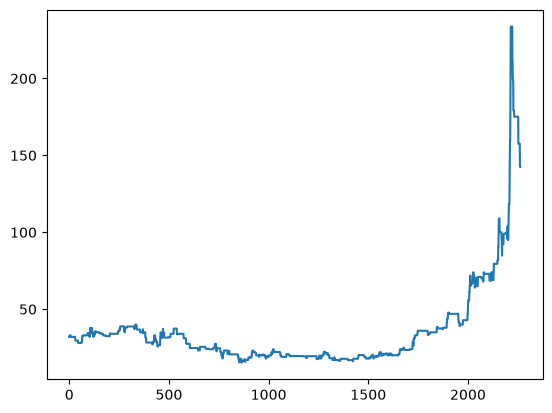

In [2]:
import matplotlib.pyplot as plt

plt.plot(cap['close_price'])
plt.show()

In [3]:
cap_end_month_df = (
    cap
    .sort_values("date")
    .groupby(cap["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

cap_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45411,CAP,2017-01-31,32.00,32.00,227404,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47233,CAP,2017-02-28,29.60,29.60,30723,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49349,CAP,2017-03-31,28.20,28.20,34714,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51176,CAP,2017-04-28,33.00,33.00,1146,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53099,CAP,2017-05-31,32.05,32.05,66496,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35272,CAP,2026-03-31,99.80,99.80,1144404,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281099,CAP,2026-04-30,145.20,145.20,1314624,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284165,CAP,2026-05-29,179.10,179.10,245407,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294093,CAP,2026-06-30,175.10,175.10,5743,2026-06-30T15:10:03.08168+00:00,6,2,2026


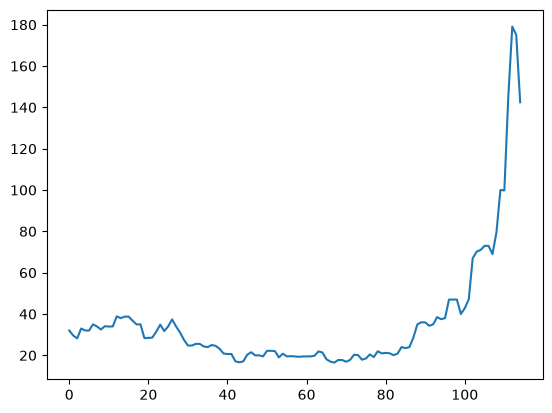

In [4]:
plt.plot(cap_end_month_df['close_price'])
plt.show()

In [5]:
cap_end_month_df['returns']=cap_end_month_df['close_price'].pct_change()*100
cap_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45411,CAP,2017-01-31,32.00,32.00,227404,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47233,CAP,2017-02-28,29.60,29.60,30723,2026-04-08T02:44:45.006295+00:00,2,1,2017,-7.500000
2,49349,CAP,2017-03-31,28.20,28.20,34714,2026-04-08T02:45:42.281198+00:00,3,1,2017,-4.729730
3,51176,CAP,2017-04-28,33.00,33.00,1146,2026-04-08T02:51:55.619599+00:00,4,2,2017,17.021277
4,53099,CAP,2017-05-31,32.05,32.05,66496,2026-04-08T02:52:57.421655+00:00,5,2,2017,-2.878788
...,...,...,...,...,...,...,...,...,...,...,...
110,35272,CAP,2026-03-31,99.80,99.80,1144404,2026-03-31T15:00:02.085058+00:00,3,1,2026,-0.249875
111,281099,CAP,2026-04-30,145.20,145.20,1314624,2026-04-30T15:00:02.170664+00:00,4,2,2026,45.490982
112,284165,CAP,2026-05-29,179.10,179.10,245407,2026-05-29T15:00:02.455558+00:00,5,2,2026,23.347107
113,294093,CAP,2026-06-30,175.10,175.10,5743,2026-06-30T15:10:03.08168+00:00,6,2,2026,-2.233389


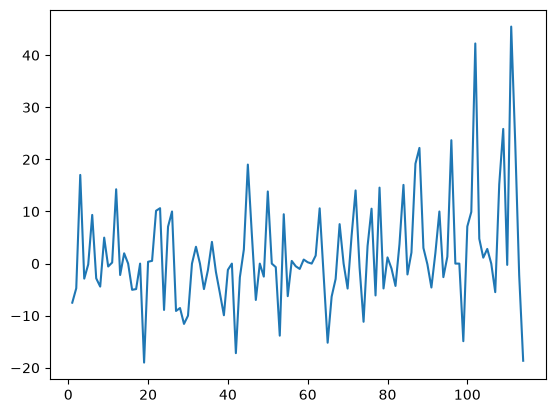

In [6]:
plt.plot(cap_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(cap_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-1.1111250679308544), np.float64(0.7106150266474052), 8, 105, {'1%': np.float64(-3.4942202045135513), '5%': np.float64(-2.889485291005291), '10%': np.float64(-2.5816762131519275)}, np.float64(753.0247850995446))
not stationary


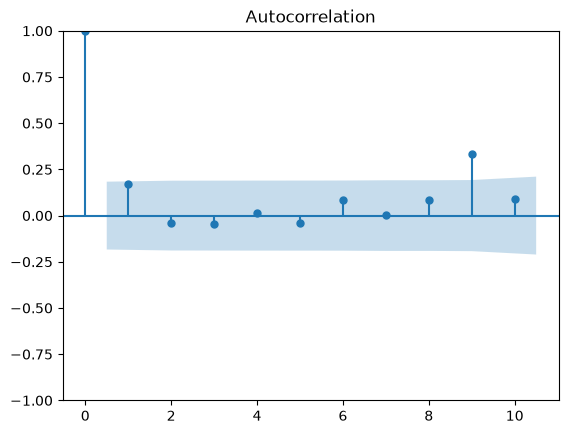

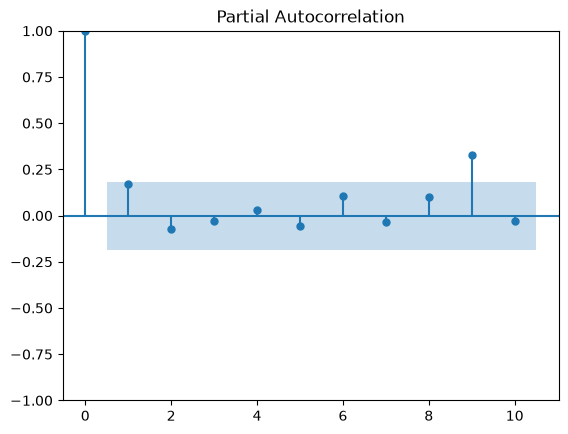

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(cap_end_month_df['returns'].dropna(), lags=10)
plot_pacf(cap_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=cap_end_month_df['close_price'][:-10]
test=cap_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -7.718174535610817]
[0, 0, 0, 0, 0, 1, -4.540917663345277]
[0, 0, 0, 0, 0, 2, -3.4851726507578746]
[0, 0, 0, 0, 1, 0, -2.6934884325471717]
[0, 0, 0, 0, 1, 1, -2.2563155952768827]
[0, 0, 0, 0, 1, 2, -2.047439413717566]
[0, 0, 0, 0, 2, 0, -1.6048528256209709]
[0, 0, 0, 0, 2, 1, -1.5981197918852237]
[0, 0, 0, 0, 2, 2, -1.624140631050361]
[0, 0, 0, 1, 0, 0, -2.8160200232095622]
[0, 0, 0, 1, 0, 1, -2.3843421388887345]
[0, 0, 0, 1, 0, 2, -2.1893397056663835]
[0, 0, 0, 1, 1, 0, -1.9588558335916968]
[0, 0, 0, 1, 1, 1, -2.01640556099809]
[0, 0, 0, 1, 1, 2, -2.1929565410788863]
[0, 0, 0, 1, 2, 0, -1.5871317030230352]
[0, 0, 0, 1, 2, 1, -1.6216330388165137]
[0, 0, 0, 1, 2, 2, -1.554196260461175]
[0, 0, 0, 2, 0, 0, -2.1787267701529314]
[0, 0, 0, 2, 0, 1, -2.206182818667491]
[0, 0, 0, 2, 0, 2, -2.324580533112308]
[0, 0, 0, 2, 1, 0, -2.012538650196209]
[0, 0, 0, 2, 1, 1, -2.014985258027256]
[0, 0, 0, 2, 1, 2, -2.221014379389516]
[0, 0, 0, 2, 2, 0, -1.6039229007788474]
[0, 0, 0, 2,

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
0,0,0,0,0,0,0,-7.718175
27,0,0,1,0,0,0,-7.443669
54,0,0,2,0,0,0,-7.299377
55,0,0,2,0,0,1,-4.571084
1,0,0,0,0,0,1,-4.540918
...,...,...,...,...,...,...,...
664,2,2,0,1,2,1,0.564953
673,2,2,0,2,2,1,0.569534
665,2,2,0,1,2,2,0.572837
674,2,2,0,2,2,2,0.574644


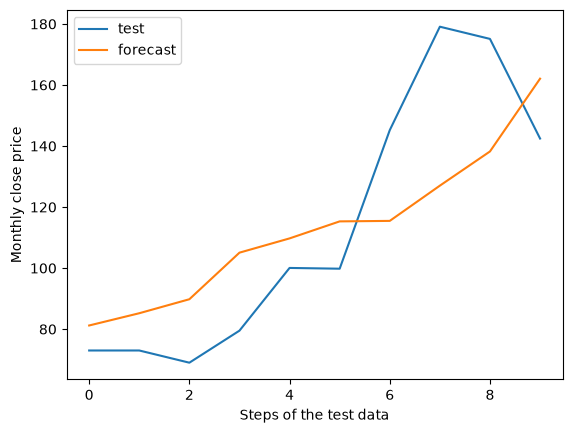

r2_score:  0.5828126041805197
rmse:  26.41575796807194
description:  count    2263.000000
mean       35.429032
std        29.046459
min        15.300000
25%        20.000000
50%        27.500000
75%        36.000000
max       233.700000
Name: close_price, dtype: float64


In [11]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=cap_end_month_df['close_price'][:-10]
y_test=cap_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,2,0), 
seasonal_order=(2,2,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', cap.close_price.describe())

Good learning. We will work with this.